In [ ]:
pip install pyreadr


In [19]:
import pyreadr

# Load the rda
rda_path = "./sysdata.rda"  # the file that printed Group/ID/Name/Hex
res = pyreadr.read_r(rda_path)

print("Objects in file:", list(res.keys()))
for name, obj in res.items():
    print("\n---", name, "---")
    print("Type:", type(obj))
    # If it's a DataFrame
    if hasattr(obj, "head") and hasattr(obj, "columns"):
        print("Columns:", list(obj.columns))
        print(obj.head(10))
    # If it's a dict/list
    elif isinstance(obj, dict):
        print("Dict keys (first 10):", list(obj.keys())[:10])
        k0 = next(iter(obj))
        v0 = obj[k0]
        print(f"Example value for {k0!r}:", v0[:5] if hasattr(v0, "__getitem__") else v0)
    # If it's a list or tuple
    elif isinstance(obj, (list, tuple)):
        print("Length:", len(obj))
        print("First 5 items:", obj[:5])
    else:
        print("Preview:", str(obj)[:500])


Objects in file: ['werner_colours']

--- werner_colours ---
Type: <class 'pandas.core.frame.DataFrame'>
Columns: ['Group', 'ID', 'Name', 'Hex']
    Group  ID                   Name      Hex
0  Whites   1             Snow White  #f1e9cd
1  Whites   2          Reddish White  #f2e7cf
2  Whites   3         Purplish White  #ece6d0
3  Whites   4        Yellowish White  #f2eacc
4  Whites   5  Orange coloured White  #f3e9ca
5  Whites   6         Greenish White  #f2ebcd
6  Whites   7     Skimmed milk White  #e6e1c9
7  Whites   8          Greyish White  #e2ddc6
8   Greys   9               Ash Grey  #cbc8b7
9   Greys  10             Smoke Grey  #bfbbb0


In [20]:


# It showed the object name is 'werner_colours'
df = res["werner_colours"].copy()
df.columns = [c.strip() for c in df.columns]  # clean just in case

# quick sanity check
df.head()

,Group,ID,Name,Hex
0,Whites,1,Snow White,#f1e9cd
1,Whites,2,Reddish White,#f2e7cf
2,Whites,3,Purplish White,#ece6d0
3,Whites,4,Yellowish White,#f2eacc
4,Whites,5,Orange coloured White,#f3e9ca


In [21]:
# Palettes by Group
palettes_by_group = {
    grp: g.sort_values("ID")["Hex"].str.strip().tolist()
    for grp, g in df.groupby("Group", sort=False)
}

# Single full palette in ID order
palettes_all = {"Werner110": df.sort_values("ID")["Hex"].str.strip().tolist()}

# Combine if you want a single dict to pass around:
palettes = {**palettes_by_group, **palettes_all}

list(palettes.keys())


['Whites',
 'Greys',
 'Blacks',
 'Blues',
 'Purples',
 'Greens',
 'Yellows',
 'Oranges',
 'Reds',
 'Browns',
 'Werner110']

In [39]:
from typing import Dict, List, Optional
import matplotlib.colors as mcolors
import ast

def to_hex_list(entry):
    # R list-of-one or stringified list cases
    if isinstance(entry, list):
        if len(entry) == 1 and isinstance(entry[0], list):
            return entry[0]
        if all(isinstance(x, str) for x in entry):
            return entry
        if len(entry) == 1 and isinstance(entry[0], str):
            s = entry[0].strip()
        else:
            raise ValueError("Unexpected palette structure.")
    elif isinstance(entry, str):
        s = entry.strip()
    else:
        raise ValueError("Unexpected palette type.")

    if s.startswith("#["):   # e.g. "#['#555152', ...]"
        s = s[1:]
    if s.startswith("["):
        return [str(x).strip().strip("'\"") for x in ast.literal_eval(s)]
    if s.startswith("c(") and s.endswith(")"):  # R c('#..','#..')
        body = s[2:-1]
        return [t.strip().strip("'\"") for t in body.split(",")]
    # fallback: comma-separated string
    return [t.strip().strip("'\"") for t in s.split(",")]


def _to_hex(s: str) -> str:
    s = str(s).strip()
    return s if s.startswith("#") else f"#{s}"

def _reverse_if_needed(seq: List[str], direction: int) -> List[str]:
    return list(reversed(seq)) if direction == -1 else list(seq)

def _interpolate_hexes(hex_list: List[str], n: int) -> List[str]:
    import numpy as np
    if not hex_list or n <= 0:
        return []
    if len(hex_list) == 1:
        return [mcolors.to_hex(mcolors.to_rgb(hex_list[0]))] * n
    cmap = mcolors.LinearSegmentedColormap.from_list("tmp", hex_list)
    xs = np.linspace(0, 1, n)
    return [mcolors.to_hex(cmap(x)) for x in xs]

def werner_brewer(palette: str,
                  n: Optional[int] = None,
                  type: str = "discrete",
                  direction: int = 1,
                  return_hex: bool = False,
                  palettes: Optional[Dict[str, List[str]]] = None):
    """
    Python analog of R's werner_brewer()
    - palette: key in `palettes` (e.g., 'Blues', 'Reds', 'Werner110')
    - n: number of colours (interpolates if you ask for more than base length)
    - type: 'discrete' or 'continuous'
    - direction: 1 (as-is) or -1 (reversed)
    - return_hex: True -> hex strings; False -> mpl-friendly colours
    - palettes: dict {name: [hex,...]}
    """
    from matplotlib.colors import ListedColormap

    if palettes is None:
        raise ValueError("Provide palettes=dict (e.g., from step 2).")
    if palette not in palettes:
        raise KeyError(f"Palette '{palette}' not found. Available: {sorted(palettes.keys())[:10]} ...")

    base = _reverse_if_needed([_to_hex(x) for x in palettes[palette]], direction)

    if type not in ("discrete", "continuous"):
        raise ValueError("type must be 'discrete' or 'continuous'")

    if type == "discrete":
        if n is None:
            n = len(base)
        out_hex = base[:n] if n <= len(base) else _interpolate_hexes(base, n)
        return out_hex if return_hex else [mcolors.to_rgb(h) for h in out_hex]

    # continuous
    if n is None:
        cmap = mcolors.LinearSegmentedColormap.from_list(f"werner_{palette}", base)
        return _interpolate_hexes(base, 256) if return_hex else cmap
    else:
        out_hex = _interpolate_hexes(base, n)
        return out_hex if return_hex else mcolors.LinearSegmentedColormap.from_list(f"werner_{palette}", out_hex)

def scale_color_werner_d(ax, palette: str, n: Optional[int] = None, direction: int = 1, palettes: Optional[Dict[str, List[str]]] = None):
    cols = werner_brewer(palette, n=n, type="discrete", direction=direction, return_hex=False, palettes=palettes)
    ax.set_prop_cycle(color=cols)
    return cols

def scale_fill_werner_d(ax, palette: str, n: Optional[int] = None, direction: int = 1, palettes: Optional[Dict[str, List[str]]] = None):
    return scale_color_werner_d(ax, palette, n=n, direction=direction, palettes=palettes)

def scale_color_werner_c(palette: str, n: Optional[int] = None, direction: int = 1, palettes: Optional[Dict[str, List[str]]] = None):
    return werner_brewer(palette, n=n, type="continuous", direction=direction, return_hex=False, palettes=palettes)

def scale_fill_werner_c(palette: str, n: Optional[int] = None, direction: int = 1, palettes: Optional[Dict[str, List[str]]] = None):
    return scale_color_werner_c(palette, n=n, direction=direction, palettes=palettes)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Colormap, ListedColormap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Colormap, ListedColormap
import matplotlib.colors as mcolors

def _pick_text_color(hex_color, prefer="white"):
    # Simple luminance check for optional auto-contrast
    r, g, b = mcolors.to_rgb(hex_color)
    L = 0.2126*r + 0.7152*g + 0.0722*b
    if prefer == "white":
        return "white" if L < 0.6 else "black"
    else:
        return "black" if L > 0.4 else "white"

def plot_palette_strip(colors_or_cmap,
                       n=None,
                       orientation="horizontal",
                       title=None,
                       figsize=(8, 1.8),
                       pad=0.02,
                       savepath=None,
                       show=True,
                       labels=None,               # list of names to show (one per swatch)
                       text_color="white",        # default: white text (as you asked)
                       fontweight="bold",
                       fontsize_name=10,
                       fontsize_hex=9,
                       auto_contrast=False        # set True to pick black/white for legibility
                       ):
    """
    Draw a palette strip with annotations: bold name (white) and hex below each box.

    colors_or_cmap : list[str] (hex) or matplotlib Colormap
    labels         : list[str] or None  (names to display above hex; len == n ideally)
    """

    print(colors_or_cmap)

    # Normalize to a list of hex colours
    if isinstance(colors_or_cmap, Colormap):
        if n is None:
            n = 9
        xs = np.linspace(0, 1, n)
        colors_rgba = [colors_or_cmap(x) for x in xs]
        colors = [mcolors.to_hex(c) for c in colors_rgba]
    else:
        colors = [mcolors.to_hex(c) for c in colors_or_cmap]
        if n is None:
            n = len(colors)
        colors = colors[:n]

    # Defaults for labels if not given
    if labels is None:
        # Only show hex in the second line; name line empty
        labels = [""] * n
    else:
        # Ensure length matches n
        if len(labels) != n:
            labels = (list(labels) + [""] * n)[:n]

    # Build the strip image: a 1×n (or n×1) matrix
    if orientation not in ("horizontal", "vertical"):
        raise ValueError("orientation must be 'horizontal' or 'vertical'")

    data = np.arange(n).reshape(1, n) if orientation == "horizontal" else np.arange(n).reshape(n, 1)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(data, aspect="auto", interpolation="nearest", cmap=ListedColormap(colors))
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Tight limits with a small padding
    if orientation == "horizontal":
        ax.set_xlim(-0.5 + pad*n, n-0.5 - pad*n)
        ax.set_ylim(1-0.5 - pad, -0.5 + pad)  # keep origin top-left feel
    else:
        ax.set_ylim(n-0.5 - pad*n, -0.5 + pad*n)
        ax.set_xlim(-0.5 + pad, 1-0.5 - pad)

    # Annotate each swatch (use Axes fraction coords so text stays centered)
    for i, (name, hex_code) in enumerate(zip(labels, colors)):
        if orientation == "horizontal":
            x_frac = (i + 0.5) / n
            y_name = 0.40   # name line
            y_hex  = 0.75   # hex line below
        else:
            # vertical strip: center horizontally, step along y
            x_frac = 0.5
            # map the i-th cell to a y-fraction band
            band_top    = (i + 1) / n
            band_bottom = i / n
            y_center    = (band_top + band_bottom) / 2
            y_name = y_center - 0.12
            y_hex  = y_center + 0.12

        tc = _pick_text_color(hex_code) if auto_contrast else text_color

        # Name (bold) — if empty, we still draw hex below
        if name:
            ax.text(x_frac, y_name, name,
                    transform=ax.transAxes,
                    ha="right", va="bottom",
                    color=tc, fontweight=fontweight, fontsize=fontsize_name)

        # Hex (uppercase)
        ax.text(x_frac, y_hex, hex_code.upper(),
                transform=ax.transAxes,
                ha="right", va="bottom",
                color=tc,
                fontsize=fontsize_hex,
                rotation=90,              # rotate counterclockwise 90°
                rotation_mode="anchor")    # keeps the anchor (ha/va) stable when rotating

    if title:
        ax.set_title(title, pad=6)

    plt.tight_layout(pad=0.1)
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, ax


In [24]:
def plot_werner_strip(palette_name,
                      palettes,
                      n=None,
                      type="discrete",
                      direction=1,
                      title=None,
                      orientation="horizontal",
                      figsize=(8,1.2),
                      **kwargs):
    """
    Pull colors from werner_brewer() and plot them as a strip.
    """
    # If you kept our earlier helper:
    cols_hex = werner_brewer(palette_name, n=n, type=type,
                             direction=direction, return_hex=True,
                             palettes=palettes)
    return plot_palette_strip(cols_hex,
                              n=len(cols_hex),
                              orientation=orientation,
                              title=title or palette_name,
                              figsize=figsize,
                              **kwargs)


['#2b2639', '#2a2854', '#5264ad', '#727c9e', '#9ead9e', '#9ead86', '#b5b57e', '#d2b852', '#9a8539']


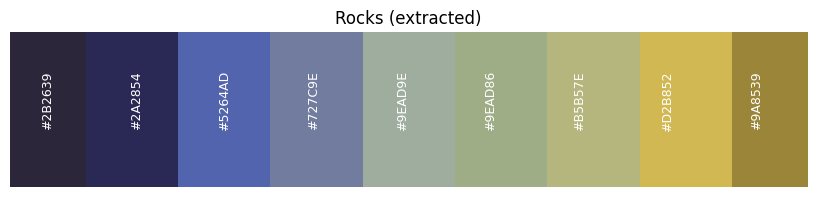

['#281f3f', '#1c1949', '#4f638d', '#383867', '#5c6b8f', '#657abb', '#6f88af', '#7994b5', '#6fb5a8']


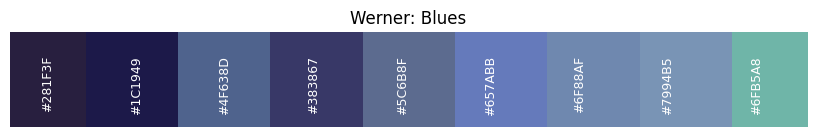

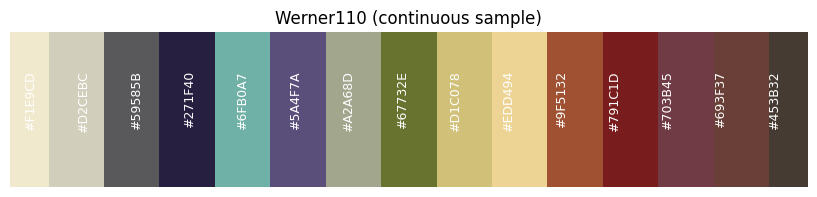

(<Figure size 800x180 with 1 Axes>,
 <Axes: title={'center': 'Werner110 (continuous sample)'}>)

In [25]:
# 1) From a list of hex
rocks = ['#2b2639','#2a2854','#5264ad','#727c9e','#9ead9e','#9ead86','#b5b57e','#d2b852','#9a8539']
plot_palette_strip(rocks, title="Rocks (extracted)", n=9)

# 2) From a Werner group using the dict you built (e.g., 'Blues', 'Reds', 'Werner110')
plot_werner_strip("Blues", palettes, n=9, type="discrete", title="Werner: Blues")

# 3) As a continuous colormap (uses interpolation)
cmap_full = scale_color_werner_c("Werner110", n=256, palettes=palettes)
plot_palette_strip(cmap_full, n=15, title="Werner110 (continuous sample)")


['#f1e9cd', '#f2e7cf', '#ede6d0', '#f0e9cd', '#f3e9cb', '#f3eacb', '#efe8cc', '#e5e0c9', '#e2ddc6']


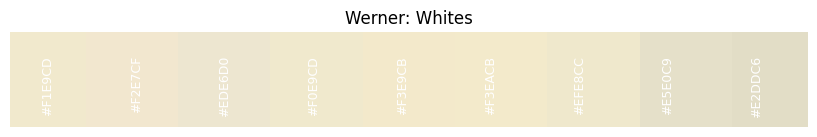

['#cbc8b7', '#c0bdb1', '#bebdb2', '#bab8af', '#b9b39e', '#aea995', '#979994', '#83867f', '#5b5c61']


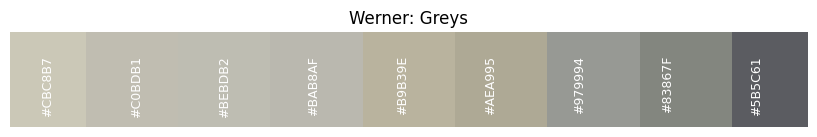

['#555152', '#464347', '#434245', '#444141', '#423937', '#433735', '#332b2c', '#252023', '#241f20']


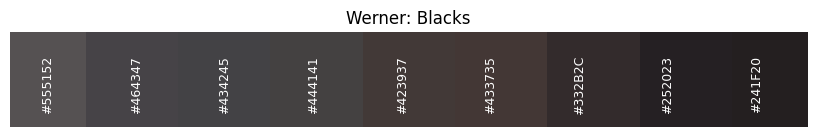

['#281f3f', '#1c1949', '#4f638d', '#383867', '#5c6b8f', '#657abb', '#6f88af', '#7994b5', '#6fb5a8']


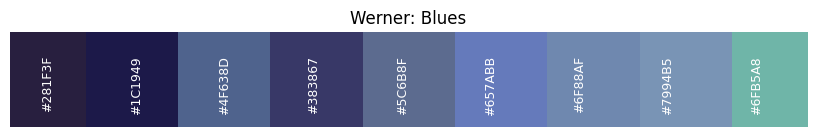

['#d0d5d3', '#8590ae', '#3a2f52', '#39334a', '#6c6d94', '#584c77', '#533552', '#463759', '#bfbac0']


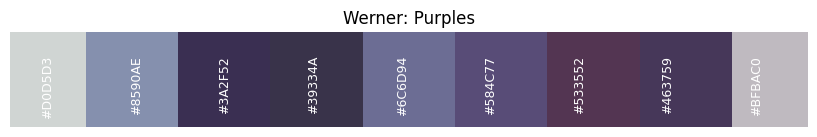

['#b8bfaf', '#b2b599', '#979c84', '#5d6161', '#61ac86', '#a4b6a7', '#adba98', '#93b778', '#7d8c55']


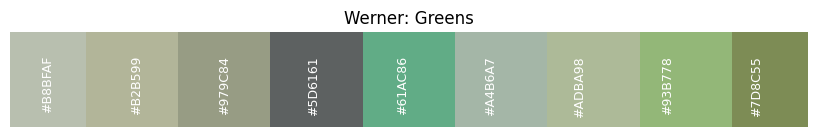

['#ccc050', '#ebdd99', '#ab9649', '#dbc364', '#e6d058', '#ead665', '#d09b2c', '#a36629', '#a77d35']


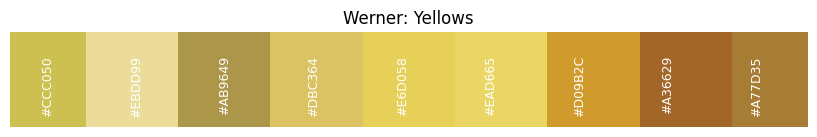

['#dfa837', '#e7b55b', '#e4ac64', '#d48445', '#b16037', '#984c33', '#b46843', '#bd6b44', '#bb603c']


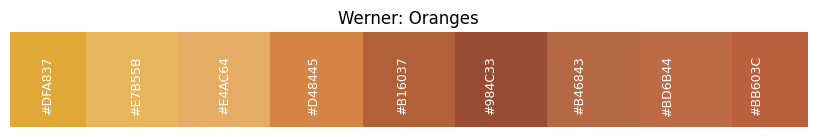

['#c76b4a', '#a75536', '#b63e36', '#b5493a', '#cd6d57', '#711518', '#e9c49d', '#eedac3', '#eecfbf']


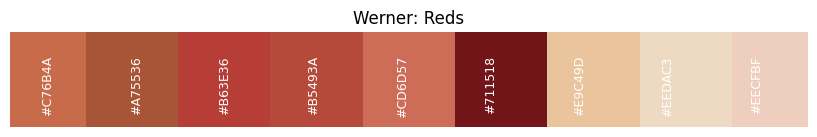

['#864735', '#553d3a', '#613936', '#7a4b3a', '#946943', '#c39e6d', '#513e32', '#8b7859', '#9b856b']


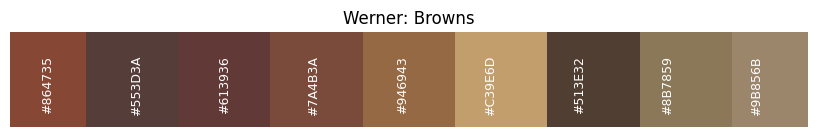

In [26]:
# Loop over each unique group in the DataFrame
for grp in df["Group"].unique():
    plot_werner_strip(
        grp,
        palettes=palettes,
        n=9,                  # or None to use full group length
        type="discrete",
        title=f"Werner: {grp}"
    )


In [27]:
  # 0) See what names exist in your df (sanity check)
sorted_names = sorted(df["Name"].astype(str).str.strip().unique())
print("Example names:", sorted_names[:20])  # scroll this to compare

# 1) Build robust lookup (normalize -> hex)
import re, unicodedata, difflib
import matplotlib.colors as mcolors

def _norm(s: str) -> str:
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii","ignore").decode("ascii")
    s = s.lower().strip()
    s = s.replace("grey","gray")  # optional: normalize grey/gray
    s = re.sub(r"[^a-z0-9]+", " ", s)  # collapse punctuation
    s = re.sub(r"\bcolou?red\b", "colored", s)  # colored/coloured
    s = re.sub(r"\s+", " ", s).strip()
    return s

name_series = df["Name"].astype(str).str.strip()
hex_series  = df["Hex"].astype(str).str.strip()

# exact (normalized) map
name2hex_exact = {_norm(n): h for n, h in zip(name_series, hex_series)}

# keep original canonical names for display
canon_norm2orig = {_norm(n): n for n in name_series}

def resolve_labels_to_hex(labels, fuzzy=True, cutoff=0.6, suggest_k=5, verbose=True):
    resolved_hex = []
    mapping = []
    unknown = {}

    valid_norm_names = list(name2hex_exact.keys())

    for lab in labels:
        keyN = _norm(lab)
        if keyN in name2hex_exact:
            resolved_hex.append(name2hex_exact[keyN])
            mapping.append((lab, canon_norm2orig[keyN]))
            continue

        if fuzzy:
            cands = difflib.get_close_matches(keyN, valid_norm_names, n=suggest_k, cutoff=cutoff)
            if cands:
                best = cands[0]
                resolved_hex.append(name2hex_exact[best])
                mapping.append((lab, canon_norm2orig[best]))
                unknown[lab] = [canon_norm2orig[c] for c in cands]
                continue

        # no match
        unknown.setdefault(lab, [])

    if verbose:
        print("Mapping:")
        for src, dst in mapping:
            print(f"  '{src}'  ->  '{dst}'")
        if unknown:
            print("\nUnresolved (with suggestions if any):")
            for k, v in unknown.items():
                print(f"  '{k}': {v or 'no close match (check df[\"Name\"])'}")

    if any(len(v)==0 for v in unknown.values()):
        # You can choose to raise, or just return partials.
        # Raise for safety so you notice mis-typed labels.
        raise ValueError("Some labels could not be resolved. See 'Unresolved' above.")

    return resolved_hex

def make_discrete_palette_from_labels(labels, return_hex=True):
    hexes = resolve_labels_to_hex(labels, fuzzy=True, cutoff=0.6, suggest_k=5, verbose=True)
    return hexes if return_hex else [mcolors.to_rgb(h) for h in hexes]


Example names: ['Apple Green', 'Arterial Blood Red', 'Ash Grey', 'Asparagus Green', 'Auricula Purple', 'Aurora Red', 'Azure Blue', 'Berlin Blue', 'Blackish Brown', 'Blackish Green', 'Blackish Grey', 'Bluish Black', 'Bluish Green', 'Bluish Grey', 'Bluish Lilac Purple', 'Bluish Purple', 'Broccoli Brown', 'Brownish Orange', 'Brownish Purple Red', 'Brownish Red']


In [28]:
import json

# Load the JSON you exported in R
with open("WernerPals.json", "r") as f:
    werner_pals = json.load(f)

# Merge into your existing palettes dict (the one with Group + Werner110)
palettes.update(werner_pals)

# Sanity check: show palette names and first few hex values
print("Available palettes:", list(palettes.keys())[:15])
print("Rocks:", palettes["Rocks"])


Available palettes: ['Whites', 'Greys', 'Blacks', 'Blues', 'Purples', 'Greens', 'Yellows', 'Oranges', 'Reds', 'Browns', 'Werner110', 'CapeVerd', 'CuttleFish', 'Rocks', 'Plants']
Rocks: [['#d0d5d3', '#8aa1a6', '#4f638d', '#3a2f52', '#241f20']]


['#555152', '#9c9d9a', '#ece6d0', '#adba98', '#6f88af']


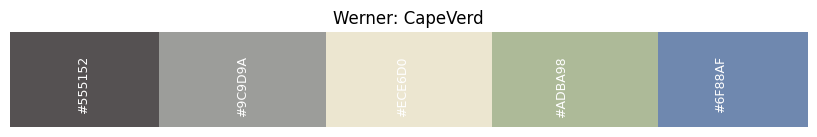

['#454445', '#7a4b3a', '#a75536', '#ebdd99', '#bebeb3']


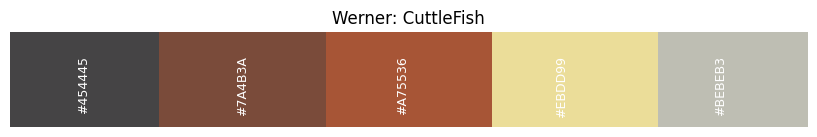

['#d0d5d3', '#8aa1a6', '#4f638d', '#3a2f52', '#241f20']


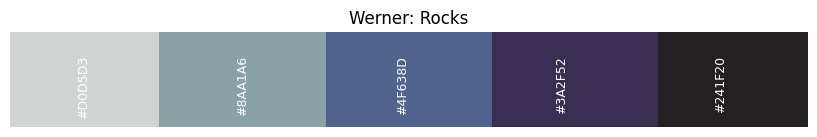

['#ebdd99', '#8e9849', '#657abb', '#b63e36', '#533552', '#252024']


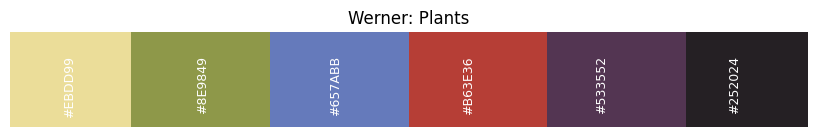

['#241f20', '#423937', '#8a8d84', '#cbc8b7', '#e2ddc6', '#ece6d0', '#f3daa7', '#ebbc71', '#d17c3f', '#864735', '#613936', '#4d3635']


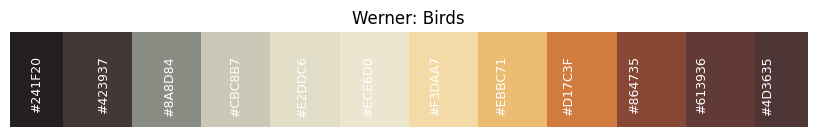

['#39334a', '#383867', '#657abb', '#8590ae', '#adba98', '#c2c190', '#dbc364', '#ab9649']


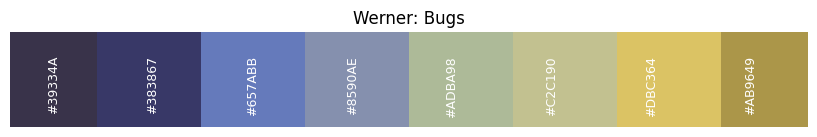

['#bfbac0', '#77747f', '#39334a', '#533552', '#92462f', '#a75536', '#be7249', '#dbc364']


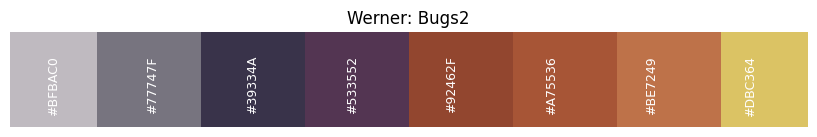

['#f3e9ca', '#f3daa7', '#ebbc71', '#d17c3f', '#864735', '#613936', '#4d3635']


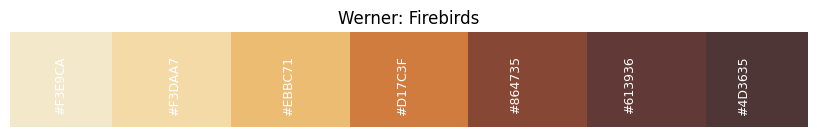

['#ece6d0', '#e2ddc6', '#cbc8b7', '#8a8d84', '#423937', '#241f20']


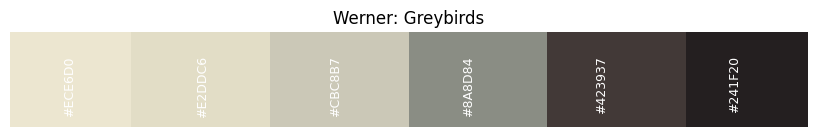

['#711518', '#b63e36', '#bb603c', '#c39e6d', '#e2ddc6', '#c8c76f', '#8e9849', '#463759', '#252024']


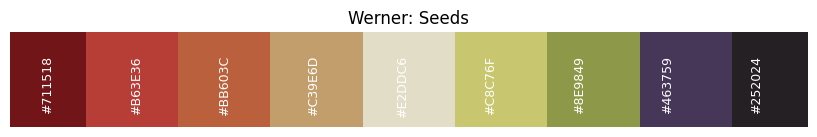

['#cd6d57', '#bb603c', '#b5493a', '#a36629', '#ab924b', '#c8c76f']


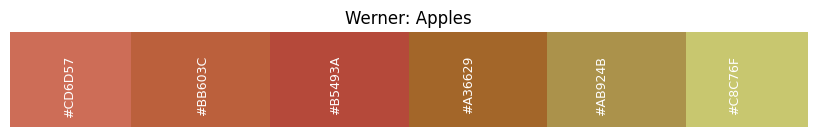

['#33431e', '#67765b', '#979c84', '#b2b599', '#b8bfaf']


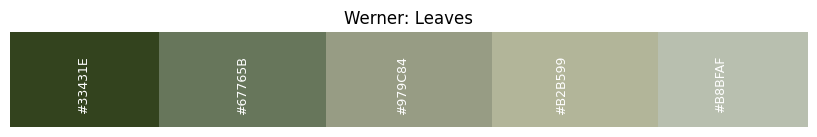

['#f1e9cd', '#f2e7cf', '#ece6d0', '#f2eacc', '#f3e9ca', '#f2ebcd', '#e6e1c9', '#e2ddc6']


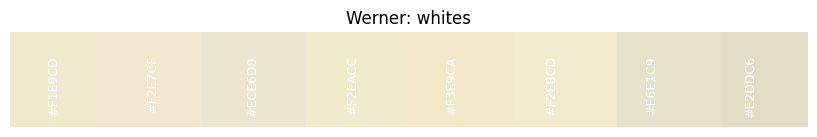

['#cbc8b7', '#bfbbb0', '#bebeb3', '#b7b5ac', '#bab191', '#9c9d9a', '#8a8d84', '#5b5c61']


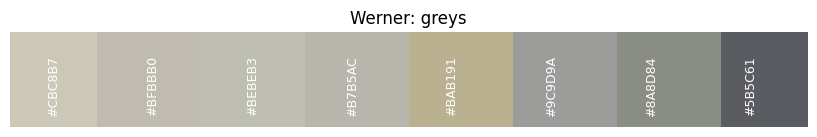

['#555152', '#413f44', '#454445', '#423937', '#433635', '#252024', '#241f20']


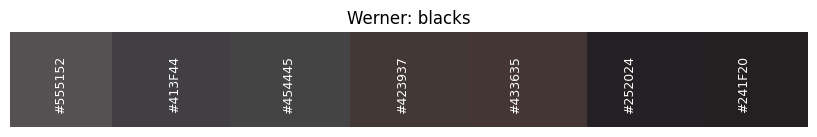

['#281f3f', '#1c1949', '#4f638d', '#383867', '#5c6b8f', '#657abb', '#6f88af', '#7994b5', '#6fb5a8', '#719ba2', '#8aa1a6']


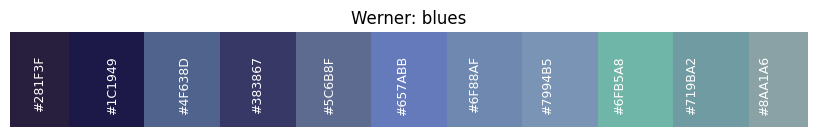

['#d0d5d3', '#8590ae', '#3a2f52', '#39334a', '#6c6d94', '#584c77', '#533552', '#463759', '#bfbac0', '#77747f', '#4a475c']


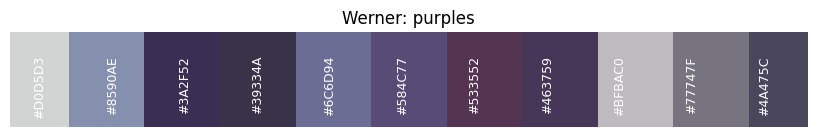

['#b8bfaf', '#b2b599', '#979c84', '#5d6161', '#61ac86', '#a4b6a7', '#adba98', '#93b778', '#7d8c55', '#33431e', '#7c8635', '#8e9849', '#c2c190', '#67765b', '#ab924b', '#c8c76f']


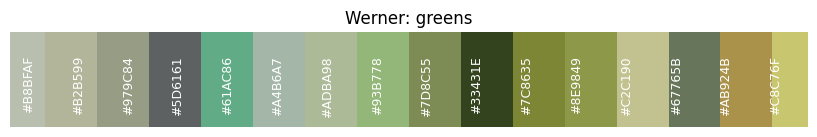

['#ccc050', '#ebdd99', '#ab9649', '#dbc364', '#e6d058', '#ead665', '#d09b2c', '#a36629', '#a77d35', '#f0d696', '#d7c485', '#f1d28c', '#efcc83', '#f3daa7']


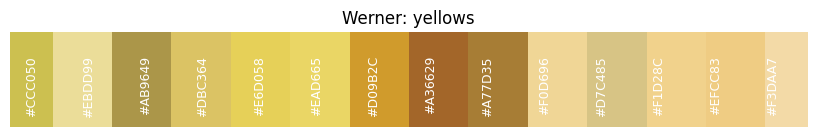

['#dfa837', '#ebbc71', '#d17c3f', '#92462f', '#be7249', '#bb603c']


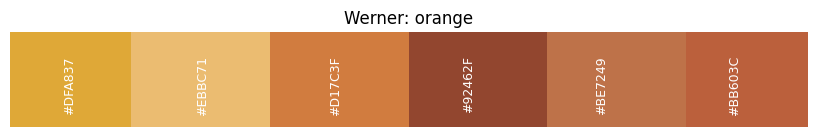

['#c76b4a', '#a75536', '#b63e36', '#b5493a', '#cd6d57', '#711518', '#e9c49d', '#eedac3', '#eecfbf', '#ce536b', '#b74a70', '#b7757c', '#612741', '#7a4848', '#3f3033', '#8d746f', '#4d3635', '#6e3b31']


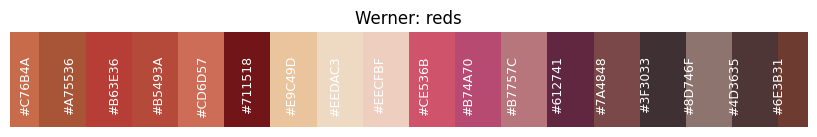

['#864735', '#553d3a', '#613936', '#7a4b3a', '#946943', '#c39e6d', '#513e32', '#8b7859', '#9b856b', '#766051', '#453b32']


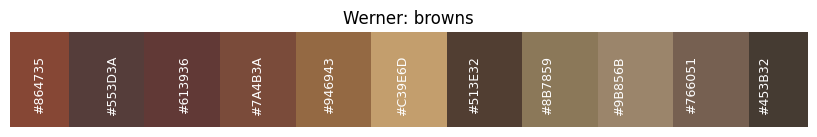

In [41]:
for name, raw in werner_pals.items():
    hex_list = to_hex_list(raw)
    plot_werner_strip(
        name,
        palettes={name: hex_list},    # pass a dict the function can index by name
        n=len(hex_list),
        type="discrete",
        title=f"Werner: {name}"
    )


In [31]:
# 0) See what names exist in your df (sanity check)
sorted_names = sorted(df["Name"].astype(str).str.strip().unique())
print("Example names:", sorted_names[:20])  # scroll this to compare

# 1) Build robust lookup (normalize -> hex)
import re, unicodedata, difflib
import matplotlib.colors as mcolors

def _norm(s: str) -> str:
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii","ignore").decode("ascii")
    s = s.lower().strip()
    s = s.replace("grey","gray")  # optional: normalize grey/gray
    s = re.sub(r"[^a-z0-9]+", " ", s)  # collapse punctuation
    s = re.sub(r"\bcolou?red\b", "colored", s)  # colored/coloured
    s = re.sub(r"\s+", " ", s).strip()
    return s

name_series = df["Name"].astype(str).str.strip()
hex_series  = df["Hex"].astype(str).str.strip()

# exact (normalized) map
name2hex_exact = {_norm(n): h for n, h in zip(name_series, hex_series)}

# keep original canonical names for display
canon_norm2orig = {_norm(n): n for n in name_series}

def resolve_labels_to_hex(labels, fuzzy=True, cutoff=0.6, suggest_k=5, verbose=True):
    resolved_hex = []
    mapping = []
    unknown = {}

    valid_norm_names = list(name2hex_exact.keys())

    for lab in labels:
        keyN = _norm(lab)
        if keyN in name2hex_exact:
            resolved_hex.append(name2hex_exact[keyN])
            mapping.append((lab, canon_norm2orig[keyN]))
            continue

        if fuzzy:
            cands = difflib.get_close_matches(keyN, valid_norm_names, n=suggest_k, cutoff=cutoff)
            if cands:
                best = cands[0]
                resolved_hex.append(name2hex_exact[best])
                mapping.append((lab, canon_norm2orig[best]))
                unknown[lab] = [canon_norm2orig[c] for c in cands]
                continue

        # no match
        unknown.setdefault(lab, [])

    if verbose:
        print("Mapping:")
        for src, dst in mapping:
            print(f"  '{src}'  ->  '{dst}'")
        if unknown:
            print("\nUnresolved (with suggestions if any):")
            for k, v in unknown.items():
                print(f"  '{k}': {v or 'no close match (check df[\"Name\"])'}")

    if any(len(v)==0 for v in unknown.values()):
        # You can choose to raise, or just return partials.
        # Raise for safety so you notice mis-typed labels.
        raise ValueError("Some labels could not be resolved. See 'Unresolved' above.")

    return resolved_hex

def make_discrete_palette_from_labels(labels, return_hex=True):
    hexes = resolve_labels_to_hex(labels, fuzzy=True, cutoff=0.6, suggest_k=5, verbose=True)
    return hexes if return_hex else [mcolors.to_rgb(h) for h in hexes]


Example names: ['Apple Green', 'Arterial Blood Red', 'Ash Grey', 'Asparagus Green', 'Auricula Purple', 'Aurora Red', 'Azure Blue', 'Berlin Blue', 'Blackish Brown', 'Blackish Green', 'Blackish Grey', 'Bluish Black', 'Bluish Green', 'Bluish Grey', 'Bluish Lilac Purple', 'Bluish Purple', 'Broccoli Brown', 'Brownish Orange', 'Brownish Purple Red', 'Brownish Red']


In [32]:
import re
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

# --- 1) Utilities ------------------------------------------------------------

def _norm_hex(h: str) -> str:
    """Normalize hex to #RRGGBB (uppercase). Accepts #RGB too."""
    h = str(h).strip()
    if not h.startswith("#"):
        h = "#" + h
    h = h.upper()
    if re.fullmatch(r"#([0-9A-F]{3})", h):
        # expand #RGB -> #RRGGBB
        h = "#" + "".join(ch*2 for ch in h[1:])
    if not re.fullmatch(r"#([0-9A-F]{6})", h):
        raise ValueError(f"Not a valid hex: {h}")
    return h

def _srgb_to_linear(c):
    return np.where(c <= 0.04045, c/12.92, ((c+0.055)/1.055)**2.4)

def _rgb_to_lab(hex_str):
    """Convert #RRGGBB (sRGB, D65) to CIE Lab."""
    rgb = np.array(mcolors.to_rgb(hex_str))  # 0..1
    # sRGB -> linear
    r_lin, g_lin, b_lin = _srgb_to_linear(rgb)
    # linear RGB -> XYZ (D65)
    M = np.array([
        [0.4124564, 0.3575761, 0.1804375],
        [0.2126729, 0.7151522, 0.0721750],
        [0.0193339, 0.1191920, 0.9503041],
    ])
    X, Y, Z = M @ np.array([r_lin, g_lin, b_lin])
    # Normalize by D65 white
    Xn, Yn, Zn = 0.95047, 1.00000, 1.08883
    x, y, z = X/Xn, Y/Yn, Z/Zn
    # XYZ -> Lab
    def f(t):
        eps, k = 216/24389, 24389/27
        return np.where(t > eps, np.cbrt(t), (k*t + 16)/116)
    fx, fy, fz = f(x), f(y), f(z)
    L = 116*fy - 16
    a = 500*(fx - fy)
    b = 200*(fy - fz)
    return np.array([L, a, b])

def _deltaE76(Lab1, Lab2):
    d = Lab1 - Lab2
    return float(np.sqrt(np.dot(d, d)))

# --- 2) Build exact and nearest-neighbor indices from your df ---------------

# assumes your df has columns: Group, ID, Name, Hex
df_norm = df.copy()
df_norm["Hex"] = df_norm["Hex"].apply(_norm_hex)

# exact: hex -> (Name, Group, ID)
hex2row = {}
for _, row in df_norm.iterrows():
    h = row["Hex"]
    if h not in hex2row:            # keep the first if any duplicates
        hex2row[h] = (row["Name"], row["Group"], int(row["ID"]))

# precompute Lab for fast nearest lookups
df_norm["Lab"] = df_norm["Hex"].apply(_rgb_to_lab)

# --- 3) Public helpers -------------------------------------------------------

def werner_label_from_hex(hex_code, top_k=3):
    """
    Return exact match if present; otherwise the top_k nearest Werner colours
    by ΔE*76 (small = closer). Always returns a dict with keys:
    - 'exact': (Name, Group, ID, Hex) or None
    - 'nearest': list of tuples (Name, Group, ID, Hex, deltaE)
    """
    h = _norm_hex(hex_code)
    # exact
    if h in hex2row:
        name, group, _id = hex2row[h]
        return {"exact": (name, group, _id, h), "nearest": []}

    # nearest
    target_lab = _rgb_to_lab(h)
    dists = df_norm["Lab"].apply(lambda L: _deltaE76(target_lab, L))
    nn = df_norm.assign(deltaE=dists).nsmallest(top_k, "deltaE")
    nearest = [
        (r["Name"], r["Group"], int(r["ID"]), r["Hex"], float(r["deltaE"]))
        for _, r in nn.iterrows()
    ]
    return {"exact": None, "nearest": nearest}

def werner_labels_for_list(hex_list, top_k=1, as_dataframe=True):
    """
    Resolve many hex codes. If as_dataframe=True, returns a tidy DataFrame with:
      query_hex | match_type | Name | Group | ID | Hex | deltaE
    """
    rows = []
    for q in hex_list:
        res = werner_label_from_hex(q, top_k=top_k)
        if res["exact"] is not None:
            name, group, _id, h = res["exact"]
            rows.append({"query_hex": _norm_hex(q), "match_type":"exact",
                         "Name": name, "Group": group, "ID": _id, "Hex": h, "deltaE": 0.0})
        else:
            for (name, group, _id, h, de) in res["nearest"]:
                rows.append({"query_hex": _norm_hex(q), "match_type":"nearest",
                             "Name": name, "Group": group, "ID": _id, "Hex": h, "deltaE": de})
    return pd.DataFrame(rows) if as_dataframe else rows


Mapping:
  'Scotch Blue'  ->  'Scotch Blue'
  'Bluish Purple'  ->  'Bluish Purple'
  'Peach Blossom Red'  ->  'Peach Blossom Red'
  'Lake Red'  ->  'Lake Red'
['#281f3f', '#8590ae', '#eecfbf', '#b74a70']
['#281f3f', '#8590ae', '#eecfbf', '#b74a70']


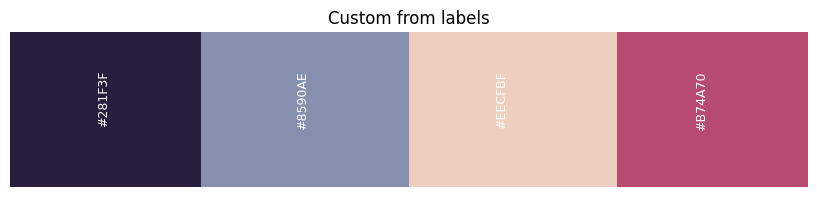

(<Figure size 800x180 with 1 Axes>,
 <Axes: title={'center': 'Custom from labels'}>)

In [33]:
labels = ["Scotch Blue", "Bluish Purple", "Peach Blossom Red", "Lake Red"]  # your list
hex_list = make_discrete_palette_from_labels(labels, return_hex=True)
print(hex_list)
plot_palette_strip(hex_list, n=len(hex_list), title="Custom from labels")


Mapping:
  'Campanula Purple'  ->  'Campanula Purple'
  'Vermilion Red'  ->  'Vermilion Red'
  'Siskin Green'  ->  'Siskin Green'
  'Leek Green'  ->  'Leek Green'
['#6c6d94', '#b5493a', '#c8c76f', '#979c84']


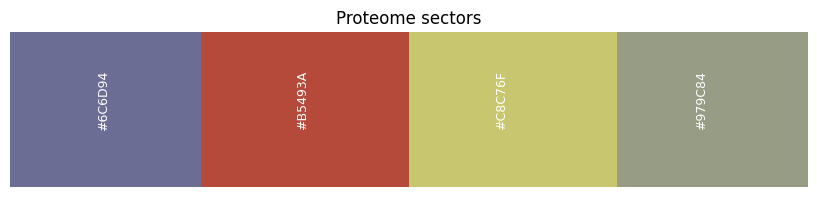

(<Figure size 800x180 with 1 Axes>,
 <Axes: title={'center': 'Proteome sectors'}>)

In [43]:
labels = ["Campanula Purple", "Vermilion Red", "Siskin Green", "Leek Green"]  # your list
hex_list = make_discrete_palette_from_labels(labels, return_hex=True)
plot_palette_strip(hex_list, n=len(hex_list), title="Proteome sectors")


In [47]:
import ast

def coerce_hex_list(x):
    if isinstance(x, str):
        s = x.strip()
        if s.startswith("#["):  # e.g. "#['#d0d5d3', ...]"
            s = s[1:]
        if s.startswith("["):
            lst = ast.literal_eval(s)
        elif s.startswith("c(") and s.endswith(")"):  # R style: c('#..','#..')
            lst = [t.strip().strip("'\"") for t in s[2:-1].split(",")]
        else:  # comma-separated fallback
            lst = [t.strip().strip("'\"") for t in s.split(",")]
    elif isinstance(x, (list, tuple)):
        lst = list(x[0]) if (len(x)==1 and isinstance(x[0], (list, tuple))) else list(x)
    else:
        raise TypeError("Unexpected palette type")

    return [c if str(c).startswith("#") else f"#{c}" for c in lst]

# Normalize the whole dict once
palettes = {k: coerce_hex_list(v) for k, v in palettes.items()}

# sanity check (will raise if still wrong)
assert isinstance(palettes["Rocks"], list) and all(isinstance(c, str) and c.startswith("#") for c in palettes["Rocks"])


['#d0d5d3', '#8aa1a6', '#4f638d', '#3a2f52']


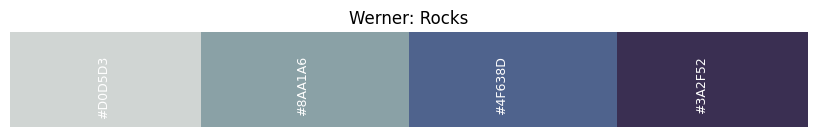

(<Figure size 800x120 with 1 Axes>, <Axes: title={'center': 'Werner: Rocks'}>)

In [48]:
plot_werner_strip("Rocks", palettes, n=4, type="discrete", title="Werner: Rocks")

['#d0d5d3', '#c3cbcb', '#b5c1c1', '#a6b6b8', '#98abaf', '#8aa1a6', '#7f95a1', '#73889c', '#677c97', '#5b6f92', '#4f638d', '#4b5981', '#474e75', '#424469', '#3e395d', '#3a2f51', '#362c48', '#31293e', '#2d2534', '#282229', '#241f20']


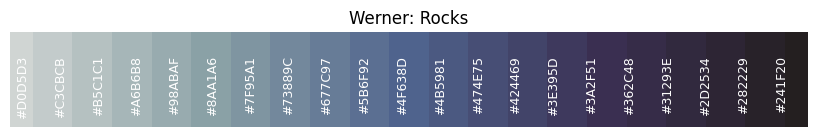

(<Figure size 800x120 with 1 Axes>, <Axes: title={'center': 'Werner: Rocks'}>)

In [49]:
plot_werner_strip("Rocks", palettes, n=21, type="discrete", title="Werner: Rocks")

['#711518', '#801e1f', '#8f2725', '#9e302c', '#b03a33', '#b74237', '#b84a38', '#b9523a', '#ba5a3b', '#bb623e', '#bd724a', '#bf8055', '#c18d60', '#c39d6c', '#c9ab7f', '#d0b892', '#d8c8a9', '#dfd6bc', '#dfdbbc', '#d9d6a9', '#d3d094', '#cdcb80', '#c7c66e', '#b8ba65', '#acb05c', '#9fa654', '#909a4a', '#81874c', '#71714f', '#5f5953', '#4f4457', '#433554', '#3b2f47', '#332a3b', '#2c2530', '#252024']


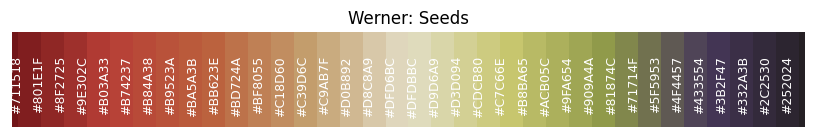

(<Figure size 800x120 with 1 Axes>, <Axes: title={'center': 'Werner: Seeds'}>)

In [50]:
plot_werner_strip("Seeds", palettes, n=36, type="continuous", title="Werner: Seeds")

['#39334a', '#393450', '#393555', '#38365b', '#383761', '#383867', '#404476', '#4a5289', '#535f99', '#5b6ca9', '#657abb', '#6b7eb8', '#7183b6', '#7887b3', '#7f8cb1', '#8590ae', '#8d99a9', '#95a1a5', '#9da9a1', '#a5b19d', '#adba98', '#b1bb96', '#b5bd95', '#babe93', '#bec092', '#c2c190', '#c7c187', '#ccc27e', '#d1c276', '#d6c36c', '#dac264', '#d1ba5e', '#c7b059', '#bda753', '#b49f4e', '#ab9649']


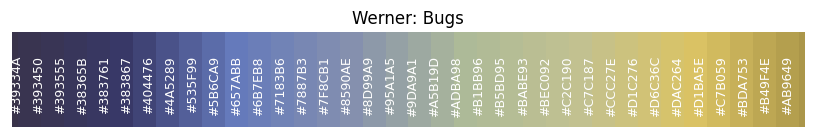

(<Figure size 800x120 with 1 Axes>, <Axes: title={'center': 'Werner: Bugs'}>)

In [52]:
plot_werner_strip("Bugs", palettes, n=36, type="continuous", title="Werner: Bugs")